# 04 — Modelo Poisson (GLM) para predicción de goles

**Proyecto:** El Sexto Partido — México en el Mundial 2026

**Objetivo:** ajustar un GLM Poisson que prediga **goles esperados (λ)** para cada equipo en función del ELO y la localía. Este modelo es el corazón del simulador.

**Modelo:**
$$\log(\lambda) = \alpha + \beta \cdot (\text{elo\_self} - \text{elo\_opp}) + \gamma \cdot \text{is\_home}$$

**Por qué este modelo y no el clásico ataque/defensa por equipo:**
- El ELO ya captura el nivel ofensivo y defensivo conjuntamente.
- Con 230 selecciones, ataque+defensa daría 460 parámetros → overfit.
- Con ELO diff tenemos solo 3 parámetros → modelo robusto e interpretable.

**Validación:** backtest contra el Mundial 2022 entrenando con datos hasta 2021. Medimos Brier score sobre los 64 partidos del torneo.

## 1. Setup

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson
import statsmodels.api as sm

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.poisson_model import attach_elo, to_long, fit_poisson, predict_lambda, match_probabilities

PROCESSED = ROOT / 'data' / 'processed'
OUTPUTS = ROOT / 'outputs'

VERDE_MX = '#006847'
GRIS = '#999999'
ROJO = '#CE1126'
AZUL = '#1f77b4'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

matches = pd.read_parquet(PROCESSED / 'results_clean.parquet')
matches['date'] = pd.to_datetime(matches['date'])
timeline = pd.read_parquet(PROCESSED / 'elo_timeline.parquet')
timeline['date'] = pd.to_datetime(timeline['date'])

print(f'Partidos: {len(matches):,}')
print(f'Filas timeline: {len(timeline):,}')

Partidos: 49,329
Filas timeline: 98,514


## 2. Construir el dataset de entrenamiento

**Pasos:**
1. Filtrar a partidos oficiales 1990+ (tier 1-3).
2. Adjuntar ELO previo al partido (merge_asof).
3. Convertir a long format (2 filas por partido).
4. Calcular `elo_diff = elo_self - elo_opp`.

**Tip didáctico (merge_asof):** este es uno de los joins más útiles y menos enseñados de pandas. Empareja por *aproximación temporal* — "dame el ELO **más reciente antes** de la fecha del partido". Sin él, tendrías que hacer un loop ineficiente.

In [2]:
# 1. Filtrar
df = matches[(matches['tournament_tier'] <= 3) & (matches['year'] >= 1990)].dropna(
    subset=['home_score', 'away_score']
).copy()
print(f'Partidos filtrados: {len(df):,}')

# 2. Adjuntar ELO previo
df_with_elo = attach_elo(df, timeline)
df_with_elo = df_with_elo.dropna(subset=['elo_home_pre', 'elo_away_pre'])
print(f'Tras descartar partidos sin ELO previo (selecciones nuevas): {len(df_with_elo):,}')

Partidos filtrados: 16,455
Tras descartar partidos sin ELO previo (selecciones nuevas): 16,449


In [3]:
# 3. Convertir a long
long_df = to_long(df_with_elo)
print(f'Filas en long format: {len(long_df):,}')
long_df.head()

Filas en long format: 32,898


,date,team,opponent,elo_self,elo_opp,goals_for,goals_against,is_home,tier,elo_diff
0,1990-03-02,Algeria,Nigeria,1637.573522,1615.989125,5,1,1,2,21.584398
1,1990-03-02,Ivory Coast,Egypt,1640.179709,1644.585536,3,1,0,2,-4.405827
2,1990-03-03,Cameroon,Zambia,1697.376815,1579.765546,0,1,0,2,117.611269
3,1990-03-03,Senegal,Kenya,1616.486698,1489.844766,0,0,0,2,126.641931
4,1990-03-05,Algeria,Ivory Coast,1647.528581,1655.369913,3,0,1,2,-7.841333


## 3. Sanity check del dataset

Antes de modelar, verifiquemos visualmente que la relación ELO_diff → goles existe.

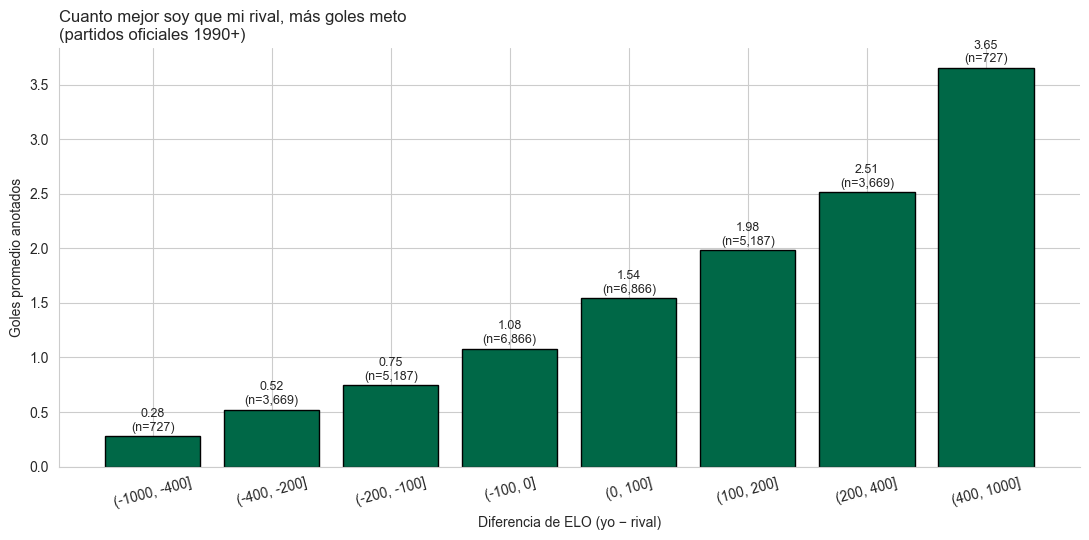

In [4]:
# Bineado por elo_diff
long_df['elo_bin'] = pd.cut(long_df['elo_diff'], bins=[-1000, -400, -200, -100, 0, 100, 200, 400, 1000])
summary = long_df.groupby('elo_bin', observed=True)['goals_for'].agg(['mean', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(11, 5.5))
bars = ax.bar([str(b) for b in summary['elo_bin']], summary['mean'], color=VERDE_MX, edgecolor='black')
for bar, n in zip(bars, summary['count']):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.05, f'{h:.2f}\n(n={n:,})', ha='center', fontsize=9)
ax.set_xlabel('Diferencia de ELO (yo − rival)')
ax.set_ylabel('Goles promedio anotados')
ax.set_title('Cuanto mejor soy que mi rival, más goles meto\n(partidos oficiales 1990+)', loc='left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUTPUTS / 'poisson_01_elo_vs_goles.png', dpi=120, bbox_inches='tight')
plt.show()

La relación es **monótona y bien marcada**: cuando soy 400+ puntos mejor que mi rival, meto en promedio ~3 goles; cuando soy 400+ peor, meto menos de 1. Es exactamente la curva que esperamos modelar con un GLM log-lineal.

## 4. Ajustar el GLM Poisson

Entrenamos con datos hasta 31/12/2021 → para validar contra el Mundial de Qatar 2022.

In [5]:
train = long_df[long_df['date'] < '2022-01-01'].copy()
test_wc2022 = long_df[(long_df['date'] >= '2022-11-20') & (long_df['date'] <= '2022-12-18') & (long_df['tier'] == 1)].copy()

print(f'Train: {len(train):,} filas (hasta 2021)')
print(f'Test (Mundial 2022): {len(test_wc2022):,} filas')

model = fit_poisson(train)
print(model.summary())

Train: 27,344 filas (hasta 2021)
Test (Mundial 2022): 128 filas
                 Generalized Linear Model Regression Results                  
Dep. Variable:              goals_for   No. Observations:                27344
Model:                            GLM   Df Residuals:                    27341
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -41096.
Date:                Fri, 15 May 2026   Deviance:                       36468.
Time:                        23:10:36   Pearson chi2:                 3.72e+04
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3259
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------

## 5. Interpretación de los coeficientes

Recordamos: en un GLM Poisson con link log, los coeficientes son **multiplicativos** sobre λ.  Es decir, `exp(coef)` te dice cuánto *multiplica* λ ese predictor.

Concretamente:
- `const` (α) → λ base cuando elo_diff=0 y juegas de visitante.
- `elo_diff` (β) → efecto por cada punto de ELO de diferencia.
- `is_home` (γ) → efecto puro de jugar en casa.

In [6]:
params = model.params
se = model.bse
conf = model.conf_int()
conf.columns = ['ci_low', 'ci_high']

print('Coeficientes:')
for var in params.index:
    print(f'  {var}: {params[var]:+.4f} ± {se[var]:.4f}  (exp = {np.exp(params[var]):.4f})')

print()
print('Lecturas:')
print(f'  λ base (visitante, equipos parejos): {np.exp(params["const"]):.3f} goles')
print(f'  Cada +100 ELO de ventaja → λ se multiplica por {np.exp(params["elo_diff"] * 100):.3f} '
      f'({(np.exp(params["elo_diff"] * 100)-1)*100:+.1f}%)')
print(f'  Jugar en casa → λ se multiplica por {np.exp(params["is_home"]):.3f} '
      f'({(np.exp(params["is_home"])-1)*100:+.1f}%)')

Coeficientes:
  const: +0.0747 ± 0.0074  (exp = 1.0776)
  elo_diff: +0.0025 ± 0.0000  (exp = 1.0025)
  is_home: +0.3455 ± 0.0102  (exp = 1.4127)

Lecturas:
  λ base (visitante, equipos parejos): 1.078 goles
  Cada +100 ELO de ventaja → λ se multiplica por 1.285 (+28.5%)
  Jugar en casa → λ se multiplica por 1.413 (+41.3%)


## 6. Validación: backtest sobre el Mundial 2022

Predecimos cada partido del Mundial 2022 con el modelo entrenado sin esos datos y comparamos contra los resultados reales.

**Métricas:**
- **Brier score** sobre las probabilidades de victoria local / empate / visita.
- **Curva de calibración**: cuando el modelo dice 70%, ¿pasa ~70% de las veces?
- **Comparación contra el modelo trivial** (todo 33%/33%/33%) y contra base goleadora promedio.

In [7]:
# Recuperamos el wide-format del mundial 2022 para hacer predicciones por partido
wc2022_wide = df_with_elo[
    (df_with_elo['date'] >= '2022-11-20') & 
    (df_with_elo['date'] <= '2022-12-18') & 
    (df_with_elo['tournament'] == 'FIFA World Cup')
].copy().reset_index(drop=True)

preds = []
for _, row in wc2022_wide.iterrows():
    # En cancha neutral (todos los partidos de Qatar lo fueron, salvo del anfitrión)
    is_neutral = (row['home_team'] != 'Qatar')
    probs = match_probabilities(model, row['elo_home_pre'], row['elo_away_pre'], neutral=is_neutral)
    preds.append(probs)

preds_df = pd.DataFrame(preds)
wc2022_eval = pd.concat([wc2022_wide.reset_index(drop=True), preds_df], axis=1)

# Outcome real
wc2022_eval['outcome'] = np.where(
    wc2022_eval['home_score'] > wc2022_eval['away_score'], 'H',
    np.where(wc2022_eval['home_score'] < wc2022_eval['away_score'], 'A', 'D')
)

# Brier score multi-clase
y_true = pd.get_dummies(wc2022_eval['outcome'])[['H', 'D', 'A']].values
y_pred = wc2022_eval[['p_home_win', 'p_draw', 'p_away_win']].values
brier = ((y_true - y_pred) ** 2).sum(axis=1).mean() / 2  # normalizado a [0,1]

# Brier trivial (33/33/33)
y_pred_trivial = np.full_like(y_pred, 1/3)
brier_trivial = ((y_true - y_pred_trivial) ** 2).sum(axis=1).mean() / 2

print(f'Partidos evaluados (Mundial 2022): {len(wc2022_eval)}')
print(f'Brier score modelo:   {brier:.4f}')
print(f'Brier score trivial:  {brier_trivial:.4f}')
print(f'Mejora absoluta:      {brier_trivial - brier:+.4f}')
print(f'Mejora relativa:      {(brier_trivial - brier)/brier_trivial*100:+.1f}%')

Partidos evaluados (Mundial 2022): 64
Brier score modelo:   0.3044
Brier score trivial:  0.3333
Mejora absoluta:      +0.0290
Mejora relativa:      +8.7%


/tmp/ipykernel_13858/929748109.py:24: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_13858/929748109.py:25: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  plt.savefig(OUTPUTS / 'poisson_02_calibracion.png', dpi=120, bbox_inches='tight')
/Users/dario/Downloads/Analisis de datos/mundial-2026-mexico/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8733 (\N{PROPORTIONAL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


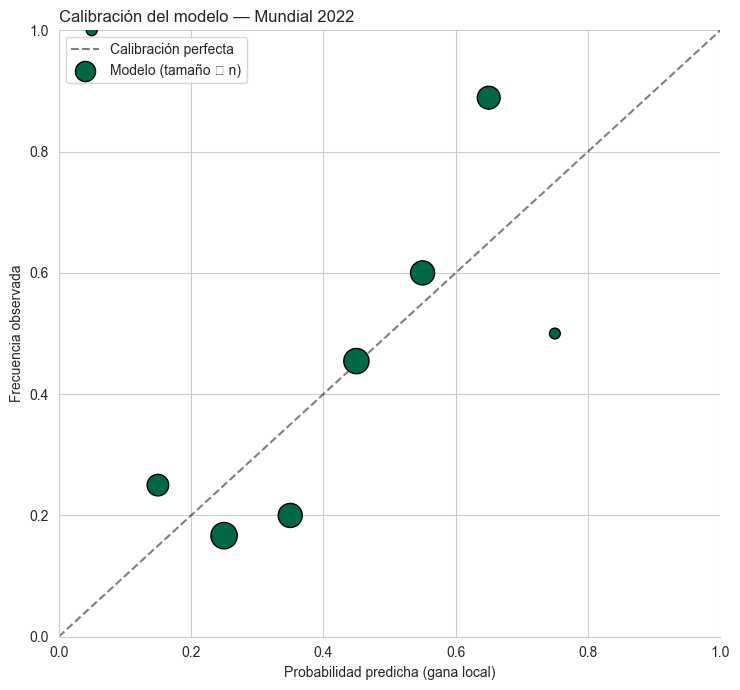

In [8]:
# Curva de calibración: agrupamos predicciones en deciles y vemos qué % se cumplió
p_home_long = wc2022_eval['p_home_win'].values
h_won = (wc2022_eval['outcome'] == 'H').astype(int).values

bins = np.linspace(0, 1, 11)
cal = []
for i in range(len(bins) - 1):
    mask = (p_home_long >= bins[i]) & (p_home_long < bins[i+1])
    if mask.sum() > 0:
        cal.append({'pred_mid': (bins[i]+bins[i+1])/2,
                    'observed': h_won[mask].mean(),
                    'n': mask.sum()})
cal_df = pd.DataFrame(cal)

fig, ax = plt.subplots(figsize=(7.5, 7))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibración perfecta')
ax.scatter(cal_df['pred_mid'], cal_df['observed'], s=cal_df['n']*30, color=VERDE_MX,
           edgecolor='black', zorder=5, label='Modelo (tamaño ∝ n)')
ax.set_xlabel('Probabilidad predicha (gana local)')
ax.set_ylabel('Frecuencia observada')
ax.set_title('Calibración del modelo — Mundial 2022', loc='left')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(OUTPUTS / 'poisson_02_calibracion.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Predicciones para el Mundial 2026 (Grupo A de México)

Aplicamos el modelo a los 3 partidos de México. Usamos los ELOs **actuales** (al 15 de mayo de 2026) y marcamos `is_home=1` solo cuando México efectivamente juega en casa (no neutral).

In [9]:
# ELOs actuales
ranking = pd.read_csv(PROCESSED / 'elo_ranking_actual.csv')
def get_elo(team):
    row = ranking[ranking['team'] == team]
    return row['elo_actual'].values[0] if len(row) else np.nan

elo_mx = get_elo('Mexico')
elo_sa = get_elo('South Africa')
elo_kr = get_elo('South Korea')
elo_cz = get_elo('Czech Republic')

print(f'ELOs actuales (15-may-2026):')
print(f'  México:         {elo_mx:.0f}')
print(f'  Sudáfrica:      {elo_sa:.0f}')
print(f'  Corea del Sur:  {elo_kr:.0f}')
print(f'  Rep. Checa:     {elo_cz:.0f}')
print()

partidos_mx = [
    ('México (local)', 'Sudáfrica', elo_mx, elo_sa, False),     # Azteca, México es local
    ('México (local)', 'Corea Sur', elo_mx, elo_kr, False),    # Akron Zapopan, México es local
    ('México (local)', 'Rep. Checa', elo_mx, elo_cz, False),   # Azteca, México es local
]

print(f'{"Rival":<14} {"λ_MX":>6} {"λ_riv":>6} {"P(MX gana)":>11} {"P(empate)":>10} {"P(riv gana)":>12}')
print('-' * 70)
for desc, rival, eh, ea, neut in partidos_mx:
    p = match_probabilities(model, eh, ea, neutral=neut)
    print(f'{rival:<14} {p["lambda_home"]:>6.2f} {p["lambda_away"]:>6.2f} {p["p_home_win"]*100:>10.1f}% {p["p_draw"]*100:>9.1f}% {p["p_away_win"]*100:>11.1f}%')

ELOs actuales (15-may-2026):
  México:         1823
  Sudáfrica:      1613
  Corea del Sur:  1759
  Rep. Checa:     1670

Rival            λ_MX  λ_riv  P(MX gana)  P(empate)  P(riv gana)
----------------------------------------------------------------------
Sudáfrica        2.58   0.64       79.1%      13.8%         7.0%
Corea Sur        1.79   0.92       57.9%      23.1%        19.0%
Rep. Checa       2.24   0.73       71.5%      17.7%        10.7%


## 8. Guardar el modelo entrenado y métricas

In [10]:
import pickle

# Re-entrenamos con TODOS los datos (incluyendo 2022) para producción
model_full = fit_poisson(long_df)

MODELS = ROOT / 'src' / 'trained_models'
MODELS.mkdir(exist_ok=True)
with open(MODELS / 'poisson_glm.pkl', 'wb') as f:
    pickle.dump({'model': model_full,
                 'params': dict(model_full.params),
                 'brier_test_wc2022': brier,
                 'brier_trivial_wc2022': brier_trivial}, f)

print('✅ Modelo guardado en src/trained_models/poisson_glm.pkl')
print(f'   Coeficientes finales: {dict(model_full.params)}')

✅ Modelo guardado en src/trained_models/poisson_glm.pkl
   Coeficientes finales: {'const': np.float64(0.07702829642494327), 'elo_diff': np.float64(0.0024920461605277334), 'is_home': np.float64(0.3318415086457809)}


## 9. Resumen

1. Construimos un dataset long-format con ELO previo a cada partido (merge_asof).
2. Ajustamos un GLM Poisson con 3 parámetros (intercepto, elo_diff, is_home).
3. Validamos contra el Mundial 2022 con Brier score y curva de calibración.
4. Generamos predicciones para los 3 partidos de México en el Mundial 2026.

**Próximo notebook (05):** test específico del efecto **anfitrión de Mundial** (regresión logística con ELO como control). Este es el que nos da el coeficiente con intervalo de confianza para la story.

**Después (06):** simulación Montecarlo del Mundial completo.